importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

print(" All libraries imported successfully!")

 All libraries imported successfully!


Upload Dataset



In [3]:

from google.colab import files
uploaded = files.upload()   # Upload: Buldhana_Dataset.xlsx

import io
filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[filename]))
print(f" Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nTarget variable stats:")
print(df['Experimental weight'].describe())

Saving Buldhana_Dataset.xlsx to Buldhana_Dataset (1).xlsx
 Dataset loaded: 154 rows × 112 columns

Target variable stats:
count    154.000000
mean       2.574208
std        0.987175
min        0.480000
25%        1.841250
50%        2.510000
75%        3.256250
max        5.700000
Name: Experimental weight, dtype: float64


Preprocessing

In [4]:
def clean_seed(val):
    v = str(val).strip().lower()
    if '335' in v or 'js' in v or 'jd' in v or 'jk' in v: return 'JS335'
    if 'fule' in v or 'phule' in v or 'sangam' in v or 'kimaya' in v: return 'Phule_Sangam'
    if 'ankur' in v: return 'Ankur'
    if 'ajit' in v: return 'Ajit'
    if 'kds' in v: return 'KDS726'
    if 'hybrid' in v: return 'Hybrid'
    if 'ruchi' in v: return 'Ruchi1001'
    if 'eagle' in v: return 'Eagle'
    return 'Other'

df['Seed_Varity_clean'] = df['Seed_Varity'].apply(clean_seed)

In [5]:
# Drop non-predictive columns
drop_cols = ['S.No.', 'Village', 'Khasra_No', 'Seed_Varity']
df2 = df.drop(columns=drop_cols)

In [6]:
# Encode categorical columns
cat_cols = ['Tehsil_Block', 'Seed_Varity_clean', 'Crop condition', 'Any_Damage', 'Weeds']
for col in cat_cols:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col].astype(str))

X = df2.drop(columns=['Experimental weight'])
y = df2['Experimental weight']

feature_names = X.columns.tolist()
print(f" Preprocessing done | Features: {X.shape[1]} | Target: Experimental weight")
print(f"Missing values: {X.isnull().sum().sum()}")

 Preprocessing done | Features: 108 | Target: Experimental weight
Missing values: 0


Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Scale for Ridge & Lasso

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f" Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

 Train size: 123  |  Test size: 31


Define Models

In [11]:
models = {
    'XGBoost': {
        'model': XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            verbosity=0
        ),
        'scaled': False
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            min_samples_leaf=3,
            random_state=42
        ),
        'scaled': False
    },
    'Ridge Regression': {
        'model': Ridge(alpha=10),
        'scaled': True
    },
    'Lasso Regression': {
        'model': Lasso(alpha=0.1, max_iter=5000),
        'scaled': True
    },
}

print(" Models defined:")
for name in models:
    print(f"   • {name}")


 Models defined:
   • XGBoost
   • Gradient Boosting
   • Ridge Regression
   • Lasso Regression


Cross-Validation

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Running 5-Fold Cross-Validation...\n")
print(f"{'Model':<22} {'R² Mean':>10} {'R² Std':>9} {'RMSE Mean':>11} {'MAE Mean':>10}")
print("-" * 65)

for name, cfg in models.items():
    m = cfg['model']
    Xin = X_train_scaled if cfg['scaled'] else X_train.values

    r2   = cross_val_score(m, Xin, y_train, cv=kf, scoring='r2')
    rmse = np.sqrt(-cross_val_score(m, Xin, y_train, cv=kf, scoring='neg_mean_squared_error'))
    mae  = -cross_val_score(m, Xin, y_train, cv=kf, scoring='neg_mean_absolute_error')

    cv_results[name] = {
        'R2_mean': r2.mean(),   'R2_std': r2.std(),
        'RMSE_mean': rmse.mean(), 'RMSE_std': rmse.std(),
        'MAE_mean': mae.mean(),   'MAE_std': mae.std()
    }
    print(f"{name:<22} {r2.mean():>10.4f} {r2.std():>9.4f} {rmse.mean():>11.4f} {mae.mean():>10.4f}")

print("\n Cross-validation complete!")

Running 5-Fold Cross-Validation...

Model                     R² Mean    R² Std   RMSE Mean   MAE Mean
-----------------------------------------------------------------
XGBoost                    0.3661    0.1288      0.7904     0.6074
Gradient Boosting          0.3391    0.1500      0.8074     0.6393
Ridge Regression           0.0552    0.1545      0.9679     0.7431
Lasso Regression           0.2973    0.1676      0.8310     0.6297

 Cross-validation complete!


Test Set Evaluation

In [13]:
test_results = {}

print("Training & evaluating on test set...\n")
print(f"{'Model':<22} {'Test R²':>10} {'Test RMSE':>11} {'Test MAE':>10}")
print("-" * 55)

for name, cfg in models.items():
    m = cfg['model']
    Xtr = X_train_scaled if cfg['scaled'] else X_train.values
    Xte = X_test_scaled  if cfg['scaled'] else X_test.values

    m.fit(Xtr, y_train)
    y_pred = m.predict(Xte)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    test_results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae,
                          'y_pred': y_pred, 'model': m}
    print(f"{name:<22} {r2:>10.4f} {rmse:>11.4f} {mae:>10.4f}")

best_name = max(test_results, key=lambda n: test_results[n]['R2'])
print(f"\n Best model: {best_name} (Test R² = {test_results[best_name]['R2']:.4f})")


Training & evaluating on test set...

Model                     Test R²   Test RMSE   Test MAE
-------------------------------------------------------
XGBoost                    0.5233      0.6108     0.5204
Gradient Boosting          0.5528      0.5916     0.5166
Ridge Regression           0.3540      0.7111     0.5905
Lasso Regression           0.4534      0.6541     0.5301

 Best model: Gradient Boosting (Test R² = 0.5528)


Results Summary Table

In [14]:
print("\n" + "="*75)
print("COMPLETE RESULTS SUMMARY")
print("="*75)
summary_rows = []
for name in models:
    cv  = cv_results[name]
    te  = test_results[name]
    summary_rows.append({
        'Model': name,
        'CV R² (mean±std)': f"{cv['R2_mean']:.4f} ± {cv['R2_std']:.4f}",
        'CV RMSE': f"{cv['RMSE_mean']:.4f}",
        'CV MAE': f"{cv['MAE_mean']:.4f}",
        'Test R²': f"{te['R2']:.4f}",
        'Test RMSE': f"{te['RMSE']:.4f}",
        'Test MAE': f"{te['MAE']:.4f}",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.index = summary_df.index + 1
print(summary_df.to_string(index=True))


COMPLETE RESULTS SUMMARY
               Model CV R² (mean±std) CV RMSE  CV MAE Test R² Test RMSE Test MAE
1            XGBoost  0.3661 ± 0.1288  0.7904  0.6074  0.5233    0.6108   0.5204
2  Gradient Boosting  0.3391 ± 0.1500  0.8074  0.6393  0.5528    0.5916   0.5166
3   Ridge Regression  0.0552 ± 0.1545  0.9679  0.7431  0.3540    0.7111   0.5905
4   Lasso Regression  0.2973 ± 0.1676  0.8310  0.6297  0.4534    0.6541   0.5301


 Plot – CV R² & RMSE Comparison

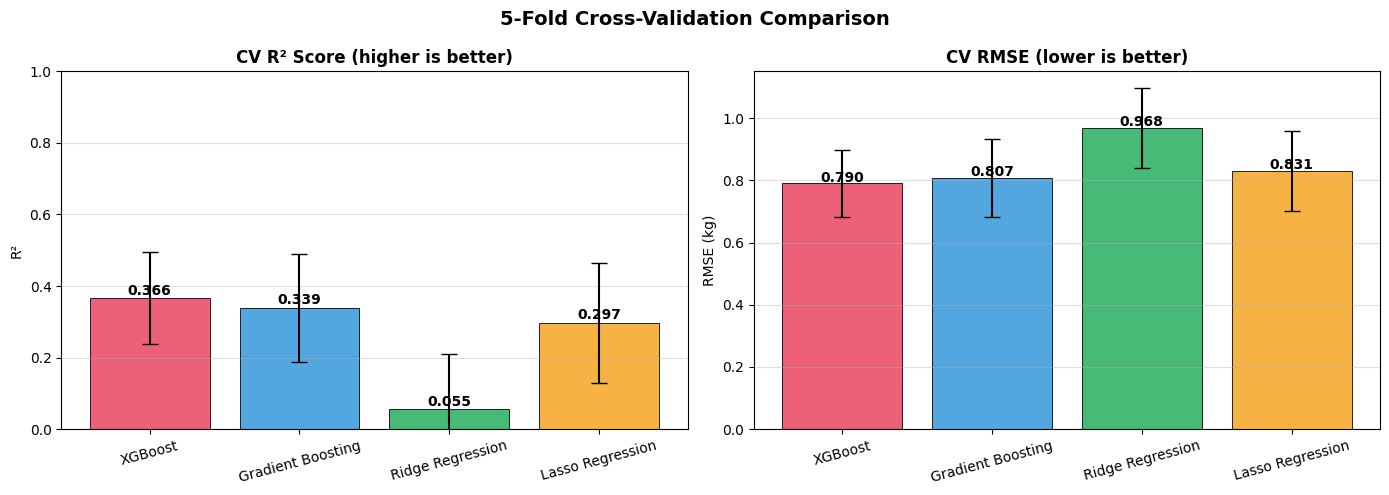

 CV comparison chart saved


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5-Fold Cross-Validation Comparison', fontsize=14, fontweight='bold')

names  = list(cv_results.keys())
colors = ['#e94560', '#3498db', '#27ae60', '#f5a623']

# R²
r2_means = [cv_results[n]['R2_mean'] for n in names]
r2_stds  = [cv_results[n]['R2_std']  for n in names]
bars = axes[0].bar(names, r2_means, yerr=r2_stds, capsize=6,
                   color=colors, alpha=0.85, edgecolor='black', linewidth=0.7)
for bar, v in zip(bars, r2_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('CV R² Score (higher is better)', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.4)

# RMSE
rmse_means = [cv_results[n]['RMSE_mean'] for n in names]
rmse_stds  = [cv_results[n]['RMSE_std']  for n in names]
bars = axes[1].bar(names, rmse_means, yerr=rmse_stds, capsize=6,
                   color=colors, alpha=0.85, edgecolor='black', linewidth=0.7)
for bar, v in zip(bars, rmse_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('CV RMSE (lower is better)', fontweight='bold')
axes[1].set_ylabel('RMSE (kg)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" CV comparison chart saved")

Plot – Predicted vs Actual (All Models)

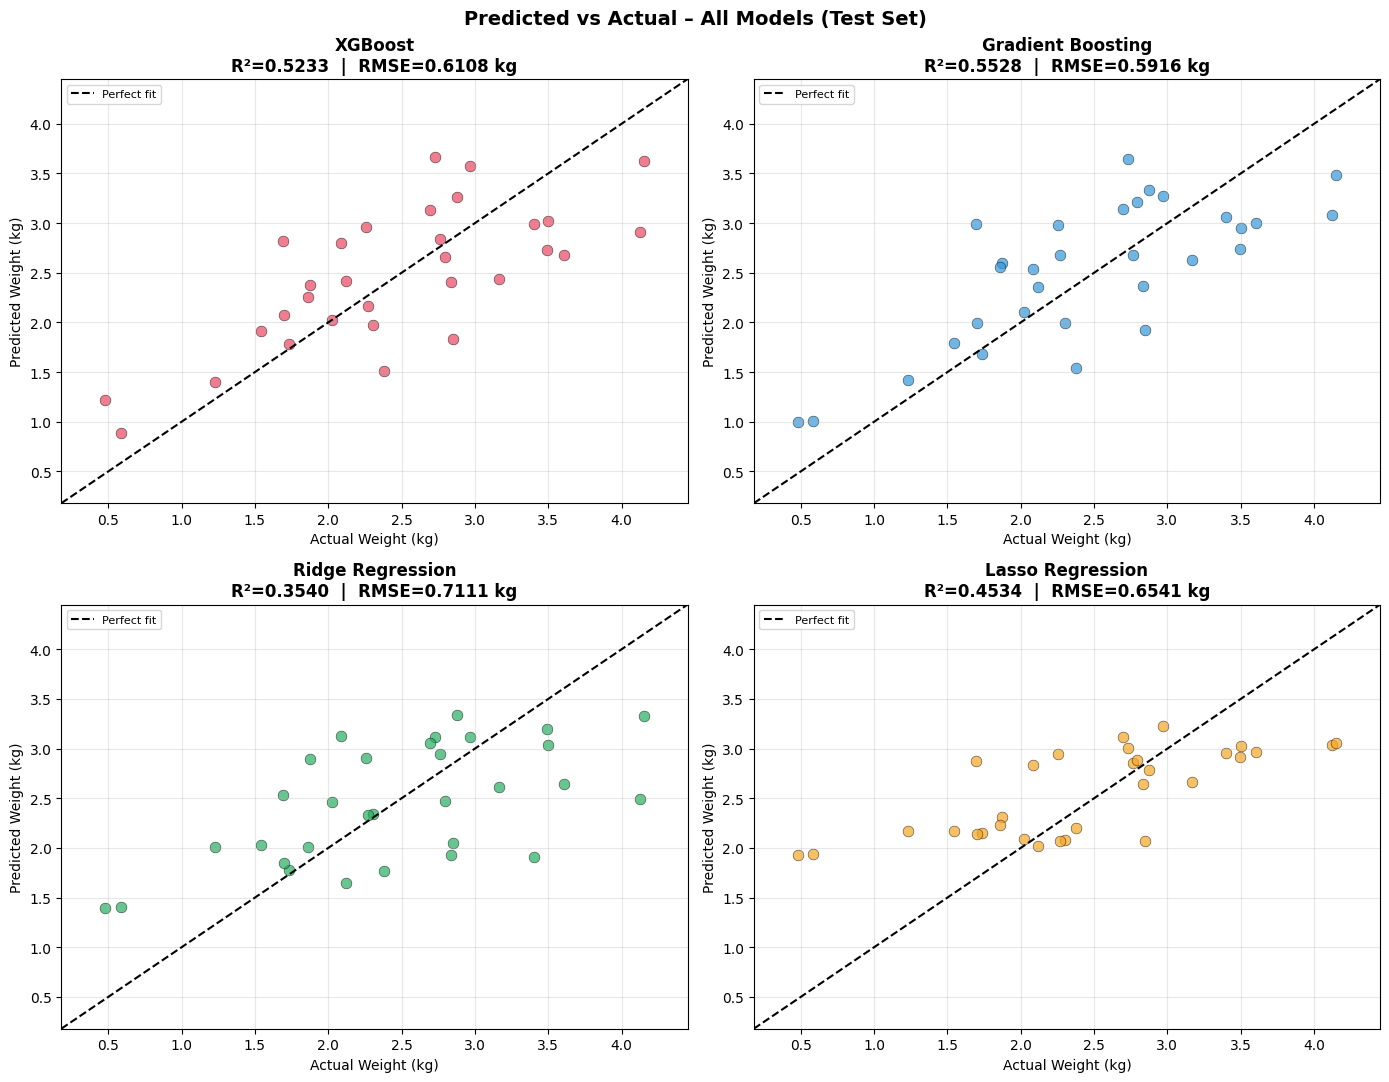

 Predicted vs Actual chart saved


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Predicted vs Actual – All Models (Test Set)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (name, color) in zip(axes, zip(test_results.keys(), colors)):
    y_pred = test_results[name]['y_pred']
    r2     = test_results[name]['R2']
    rmse   = test_results[name]['RMSE']

    ax.scatter(y_test, y_pred, color=color, alpha=0.7,
               edgecolors='black', linewidth=0.4, s=60)
    lims = [min(y_test.min(), y_pred.min()) - 0.3,
            max(y_test.max(), y_pred.max()) + 0.3]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect fit')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f'{name}\nR²={r2:.4f}  |  RMSE={rmse:.4f} kg',
                 fontweight='bold')
    ax.set_xlabel('Actual Weight (kg)')
    ax.set_ylabel('Predicted Weight (kg)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Predicted vs Actual chart saved")

Plot – Residuals (All Models

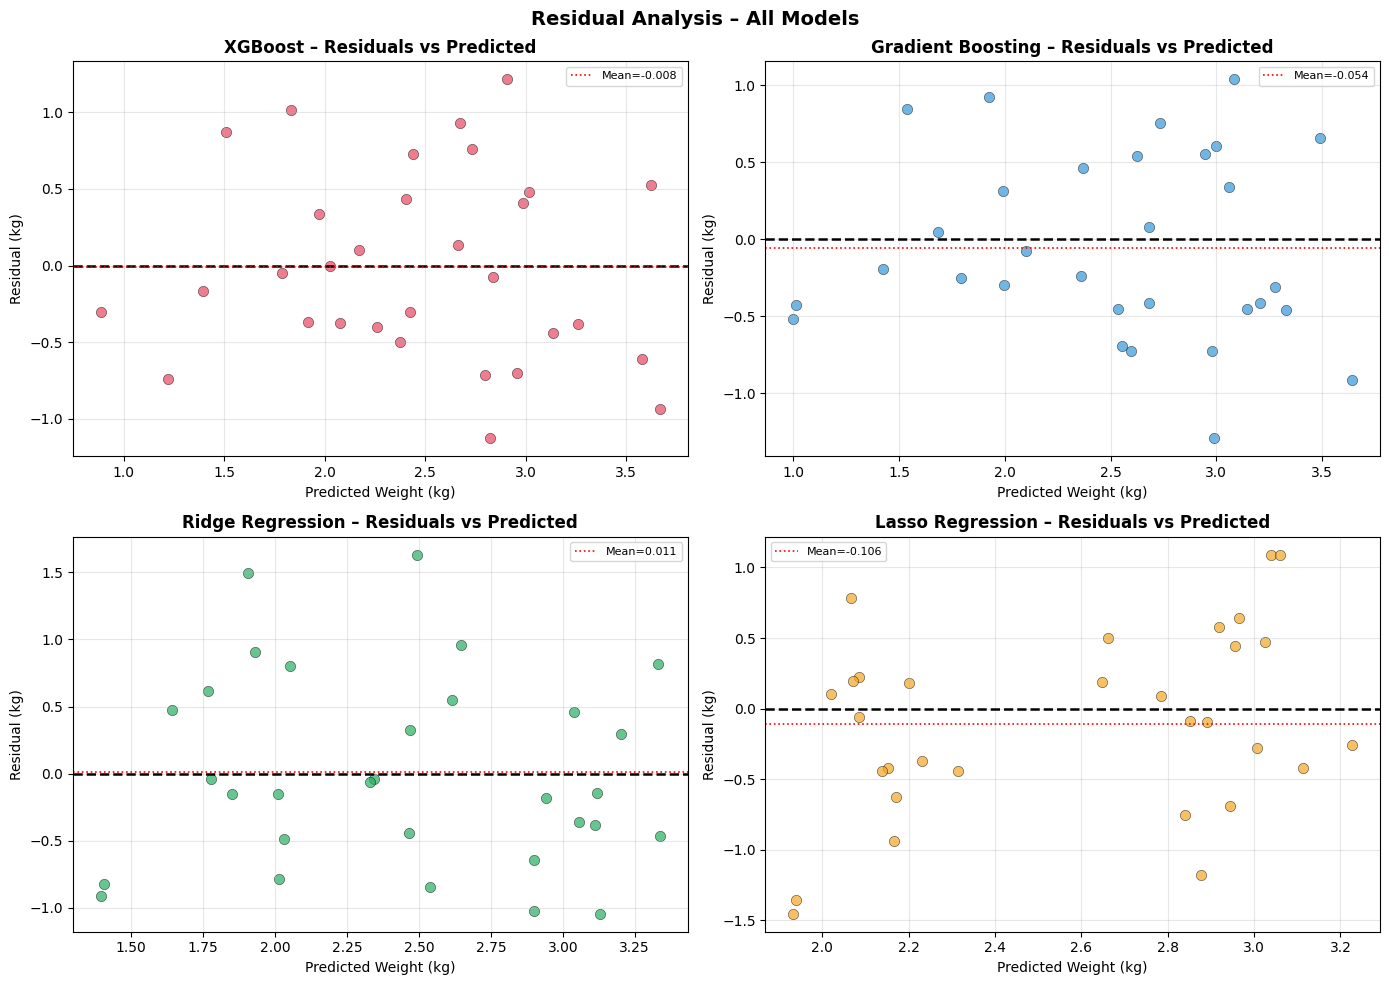

 Residuals chart saved


In [17]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Analysis – All Models', fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (name, color) in zip(axes, zip(test_results.keys(), colors)):
    y_pred    = test_results[name]['y_pred']
    residuals = np.array(y_test) - y_pred

    ax.scatter(y_pred, residuals, color=color, alpha=0.7,
               edgecolors='black', linewidth=0.4, s=55)
    ax.axhline(0, color='black', linewidth=1.8, linestyle='--')
    ax.axhline(residuals.mean(), color='red', linewidth=1.2,
               linestyle=':', label=f'Mean={residuals.mean():.3f}')
    ax.set_title(f'{name} – Residuals vs Predicted', fontweight='bold')
    ax.set_xlabel('Predicted Weight (kg)')
    ax.set_ylabel('Residual (kg)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Residuals chart saved")

Feature Importance (Tree Models)

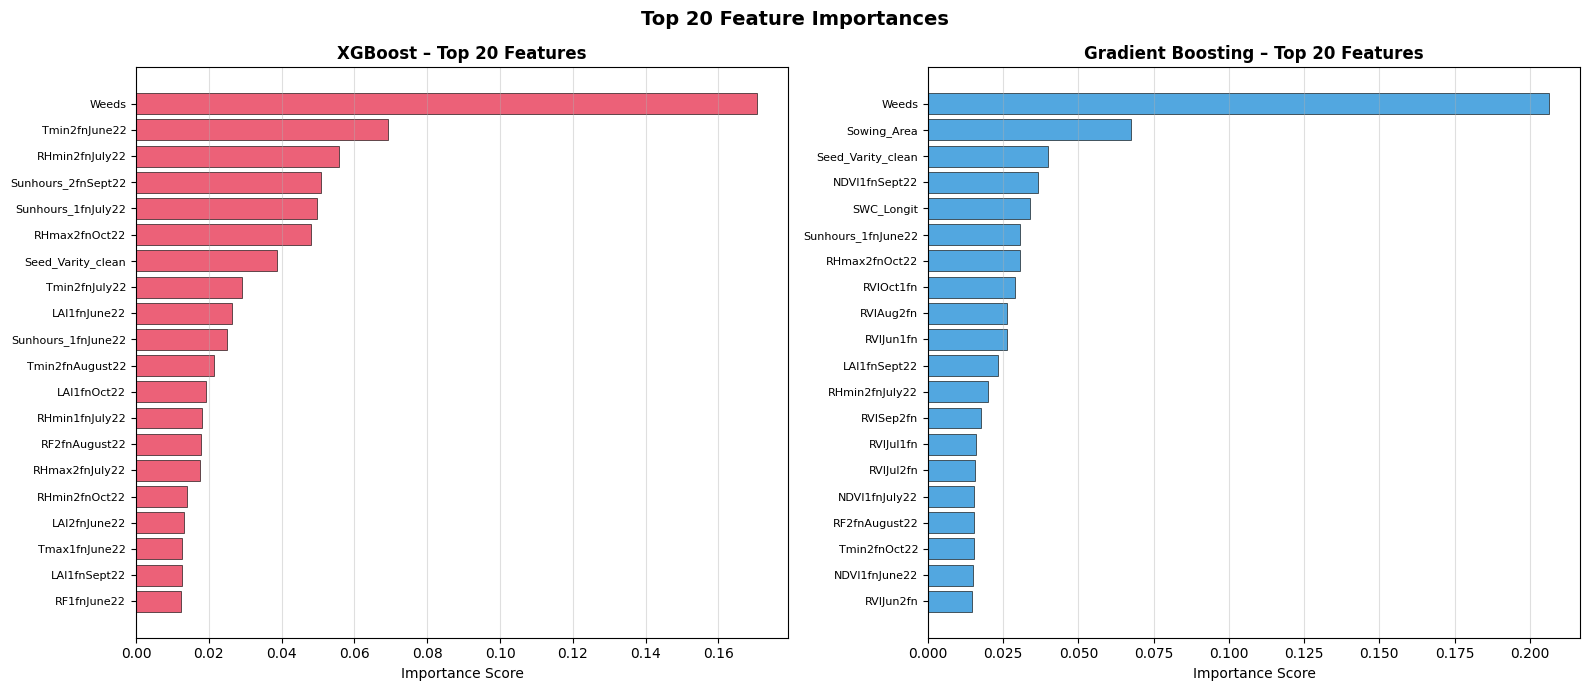

 Feature importance chart saved


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top 20 Feature Importances', fontsize=14, fontweight='bold')

tree_models = {
    'XGBoost':          ('#e94560', test_results['XGBoost']['model']),
    'Gradient Boosting':('#3498db', test_results['Gradient Boosting']['model']),
}

for ax, (name, (color, model)) in zip(axes, tree_models.items()):
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(20)
    ax.barh(imp.index[::-1], imp.values[::-1], color=color, alpha=0.85,
            edgecolor='black', linewidth=0.5)
    ax.set_title(f'{name} – Top 20 Features', fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Feature importance chart saved")